In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

# ---------------------------------------------------------------- paths ----
DATA_FILE = Path("conceptual_framework_revised_review_data_August.xlsx")
OUTDIR = Path("figures")
OUTDIR.mkdir(exist_ok=True)

# ------------------------------------------------------- canvas and type ----
# The April 2026 figures were saved at 150 dpi. Dividing their pixel dimensions
# by 150 recovers the figsize in inches, so these come out at the same page size.
APRIL_DPI = 150
APRIL_PIXELS = {3: (1784, 947), 4: (1399, 975), 5: (1675, 746),
                6: (1633, 806), 7: (1637, 1035)}
FIGSIZE = {n: (w / APRIL_DPI, h / APRIL_DPI) for n, (w, h) in APRIL_PIXELS.items()}

DPI = 600     # the one change: 4x the linear resolution of the April set

# Point sizes measured off the April figures (text widths solved back to points).
FONTS = dict(tick=11, bar=10, axis=11, title=12,
             legend=9, legend_title=10, map=9, cbar_label=13)

# ------------------------------------------------------------ geography ----
NE_SCALE = "50m"         # "50m" resolves all 23 M49 subregions; "110m" drops the Pacific
REGION_GEOJSON = Path(f"un_m49_regions_{NE_SCALE}.geojson")
REGION_SHP_DIR = Path(f"un_m49_regions_{NE_SCALE}_shp")

# ------------------------------------------------------------- palettes ----
# Sampled from the April figures so colours carry across versions.
ORIGIN_ORDER = ["Environmental", "Social", "Economic"]
ORIGIN_COLORS = {"Environmental": "#4CAF50", "Social": "#FFA726", "Economic": "#9E9E9E"}

IMPACT_ORDER = ["Negative", "Positive"]
IMPACT_COLORS = {"Negative": "#FFB2B2", "Positive": "#AAAAFF"}

SUPPLY_ORDER = [
    "Direct impact on Demand",
    "Direct impact on Flow",
    "Direct impact on Supply",
    "Indirect impact on Demand",
    "Indirect impact on Flow",
    "Indirect impact on Supply",
]
SUPPLY_COLORS = {
    "Direct impact on Demand": "#2D1A4A",
    "Direct impact on Flow": "#4B2D7A",
    "Direct impact on Supply": "#7A6FA8",
    "Indirect impact on Demand": "#9A6FA0",
    "Indirect impact on Flow": "#A97AA3",
    "Indirect impact on Supply": "#B87AA5",
}
SUPPLY_LABELS = {
    "Direct impact on Demand": "Direct Demand",
    "Direct impact on Flow": "Direct Flow",
    "Direct impact on Supply": "Direct Supply",
    "Indirect impact on Demand": "Indirect Demand",
    "Indirect impact on Flow": "Indirect Flow",
    "Indirect impact on Supply": "Indirect Supply",
}

MAP_CMAP = "cool"

# ---------------------------------------------------- global-scope studies ----
# Three studies are coded to all 23 M49 subregions, i.e. global in scope. They count
# towards every other figure, but including them in the map adds one count to all 23
# regions each, inflating every region by 3 and making the map read as far more evenly
# studied than the evidence supports. The Figure 3 caption states they are excluded, so
# they are excluded here. Set to False to see the other basis.
EXCLUDE_GLOBAL_FROM_MAP = True

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": None,      # honour the canvas; never crop to drawn content
    "figure.dpi": 110,
})

In [2]:
NE_URL = ("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/"
          f"master/geojson/ne_{NE_SCALE}_admin_0_countries.geojson")

# Natural Earth's one spelling difference from the M49 list used in the sheet.
M49_FIXES = {"South-Eastern Asia": "South-eastern Asia"}


def build_region_layer(force: bool = False) -> gpd.GeoDataFrame:
    """Dissolve Natural Earth countries into UN M49 subregions (cached on disk)."""
    if REGION_GEOJSON.exists() and not force:
        return gpd.read_file(REGION_GEOJSON)

    world = gpd.read_file(NE_URL)
    world = world[world["SUBREGION"].notna()]
    world = world[world["SUBREGION"] != "Seven seas (open ocean)"].copy()
    world["region"] = world["SUBREGION"].replace(M49_FIXES)

    regions = world.dissolve(by="region")[["geometry"]].reset_index()
    regions = regions.set_crs("EPSG:4326", allow_override=True)

    regions.to_file(REGION_GEOJSON, driver="GeoJSON")
    REGION_SHP_DIR.mkdir(exist_ok=True)
    regions.to_file(REGION_SHP_DIR / "un_m49_regions.shp")
    return regions


regions_gdf = build_region_layer()
print(f"{len(regions_gdf)} UN M49 subregions -> {REGION_GEOJSON}, {REGION_SHP_DIR}/")

23 UN M49 subregions -> un_m49_regions_50m.geojson, un_m49_regions_50m_shp/


In [3]:
EVENT_LABEL_MAX = 30   # labels longer than this get their parenthetical trimmed
MAX_ES_BLOCKS = 8      # how many "Ecosystem service N" column blocks to look for


def split_list(value):
    """Split a semicolon-delimited cell into clean tokens."""
    if pd.isna(value):
        return []
    return [p.strip() for p in str(value).split(";") if p.strip()]


def tidy_event(token: str) -> str:
    """Trim an event cell down to its axis label.

    'Other: Hyper Salinity event'                          -> 'Other'
    'Human-caused accident (Dam collapse, oil spill, ...)' -> 'Human-caused accident'
    'Winter storm (snow, ice)'                             -> kept as-is (short enough)
    """
    token = token.split(":")[0].strip()
    if len(token) > EVENT_LABEL_MAX:
        token = token.split("(")[0].strip()
    return token


def is_global_scope(df: pd.DataFrame) -> pd.Series:
    """True where a study's region field lists every subregion coded anywhere in the sheet.

    Derived from the data rather than hard-coded, so it stays correct if the sheet changes.
    """
    n_all = len({reg for _, r in df.iterrows()
                 for reg in split_list(r["Geographic region"])})
    return df["Geographic region"].map(lambda v: len(split_list(v)) >= n_all)


def region_counts(df: pd.DataFrame, exclude_global: bool = True) -> pd.Series:
    """One count per study per subregion it covers.

    With `exclude_global`, studies coded to every subregion are dropped first - see
    EXCLUDE_GLOBAL_FROM_MAP in the setup cell.
    """
    sub = df[~is_global_scope(df)] if exclude_global else df
    rows = [reg for _, r in sub.iterrows() for reg in split_list(r["Geographic region"])]
    return pd.Series(rows).value_counts()


def event_frame(df: pd.DataFrame) -> pd.DataFrame:
    """One row per event mention per study, with that study's event origin."""
    rows = []
    for _, r in df.iterrows():
        origin = str(r["Event Origin"]).strip() if pd.notna(r["Event Origin"]) else "Unknown"
        for tok in split_list(r["What was the event?"]):
            rows.append({"event": tidy_event(tok), "origin": origin})
    return pd.DataFrame(rows)


def es_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Stack the numbered ES / impact / supply-chain column blocks into a tidy table."""
    rows = []
    for _, r in df.iterrows():
        events = [tidy_event(t) for t in split_list(r["What was the event?"])]
        for i in range(1, MAX_ES_BLOCKS + 1):
            es_col = f"Ecosystem service {i}"
            im_col = f"Impact direction {i}"
            sc_col = f"Supply chain element {i}"
            if es_col not in r.index or pd.isna(r[es_col]):
                continue
            rows.append({
                "study": r.get("Covidence #"),
                "events": events,
                "es": str(r[es_col]).strip(),
                "impact": str(r[im_col]).strip() if pd.notna(r.get(im_col)) else None,
                "supply": str(r[sc_col]).strip() if pd.notna(r.get(sc_col)) else None,
            })
    return pd.DataFrame(rows)


df = pd.read_excel(DATA_FILE)
df.columns = [str(col).strip() for col in df.columns]

is_global = is_global_scope(df)
counts = region_counts(df, exclude_global=EXCLUDE_GLOBAL_FROM_MAP)
events = event_frame(df)
es = es_frame(df)

# Figure 3 basis - these four numbers are the ones quoted in its caption.
map_df = df[~is_global] if EXCLUDE_GLOBAL_FROM_MAP else df
n_represented = len(map_df)
n_displayed = int(counts.sum())
n_multi = int(map_df["Geographic region"].map(lambda v: len(split_list(v)) > 1).sum())
all_coded_regions = {reg for _, r in df.iterrows()
                     for reg in split_list(r["Geographic region"])}
no_data_regions = sorted(all_coded_regions - set(counts.index))

print(f"{len(df)} studies | {len(events)} event mentions | {len(es)} ES records")
print(f"\nglobal-scope studies ({int(is_global.sum())}), "
      f"{'excluded from' if EXCLUDE_GLOBAL_FROM_MAP else 'included in'} Figure 3:")
for _, r in df[is_global].iterrows():
    print(f"   #{r['Covidence #']} {r['Study ID']} - {r['What was the event?']}")
print(f"\nFigure 3 basis: {n_represented} studies, {n_displayed} counts, "
      f"{len(counts)} regions with data, max {counts.max()} ({counts.idxmax()})")
if no_data_regions:
    print(f"   {len(no_data_regions)} region(s) with no data: {', '.join(no_data_regions)}")

incomplete = es[es["impact"].isna() | es["supply"].isna()]
if len(incomplete):
    print(f"\n{len(incomplete)} ES record(s) missing impact direction or supply-chain element:")
    print(incomplete[["study", "es", "impact", "supply"]].to_string(index=False))

121 studies | 123 event mentions | 316 ES records

global-scope studies (3), excluded from Figure 3:
   #1082 Ferreira 2025 - Oceanic Heatwave
   #1165 Straffelini 2024 - Drought
   #1986 Price 2021 - Pandemic

Figure 3 basis: 118 studies, 127 counts, 20 regions with data, max 20 (Eastern Asia)
   3 region(s) with no data: Central Asia, Middle Africa, Western Africa

1 ES record(s) missing impact direction or supply-chain element:


 study                               es impact supply
    14 Habitat Creation and Maintenance    NaN    NaN


In [4]:
def pivot_counts(long_df, index_col, stack_col, stack_order):
    """Cross-tabulate to a category x stack matrix, alphabetical bottom-to-top."""
    tab = long_df.groupby([index_col, stack_col]).size().unstack(fill_value=0)
    for col in stack_order:
        if col not in tab.columns:
            tab[col] = 0
    tab = tab[[col for col in stack_order if col in tab.columns]]
    return tab.sort_index(ascending=False).iloc[::-1]


def stacked_barh(ax, matrix, cat_order, colors, labels=None, min_label=1):
    """Draw a stacked horizontal bar chart with in-bar count labels."""
    ypos = np.arange(len(matrix.index))
    left = np.zeros(len(matrix.index))
    for cat in cat_order:
        if cat not in matrix.columns:
            continue
        vals = matrix[cat].values.astype(float)
        ax.barh(ypos, vals, left=left, height=0.62, color=colors[cat],
                label=(labels or {}).get(cat, cat), zorder=2)
        for y, v, l in zip(ypos, vals, left):
            if v >= min_label:
                ax.text(l + v / 2, y, f"{int(v)}", ha="center", va="center", color="white",
                        fontsize=FONTS["bar"], fontweight="bold", zorder=3)
        left += vals
    ax.set_yticks(ypos)
    ax.set_yticklabels(matrix.index, fontsize=FONTS["tick"])
    ax.set_ylim(-0.7, len(matrix.index) - 0.3)
    ax.tick_params(axis="y", length=0)
    return left


def outside_legend(ax, handles, title=None):
    """Legend outside the axes on the upper right, as in the April figures."""
    return ax.legend(handles=handles, title=title, loc="upper left",
                     bbox_to_anchor=(1.01, 1.0), fontsize=FONTS["legend"],
                     title_fontsize=FONTS["legend_title"])


def plain_axis(ax):
    """Strip the x axis entirely (Figures 4 and 5)."""
    ax.set_xticks([])
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

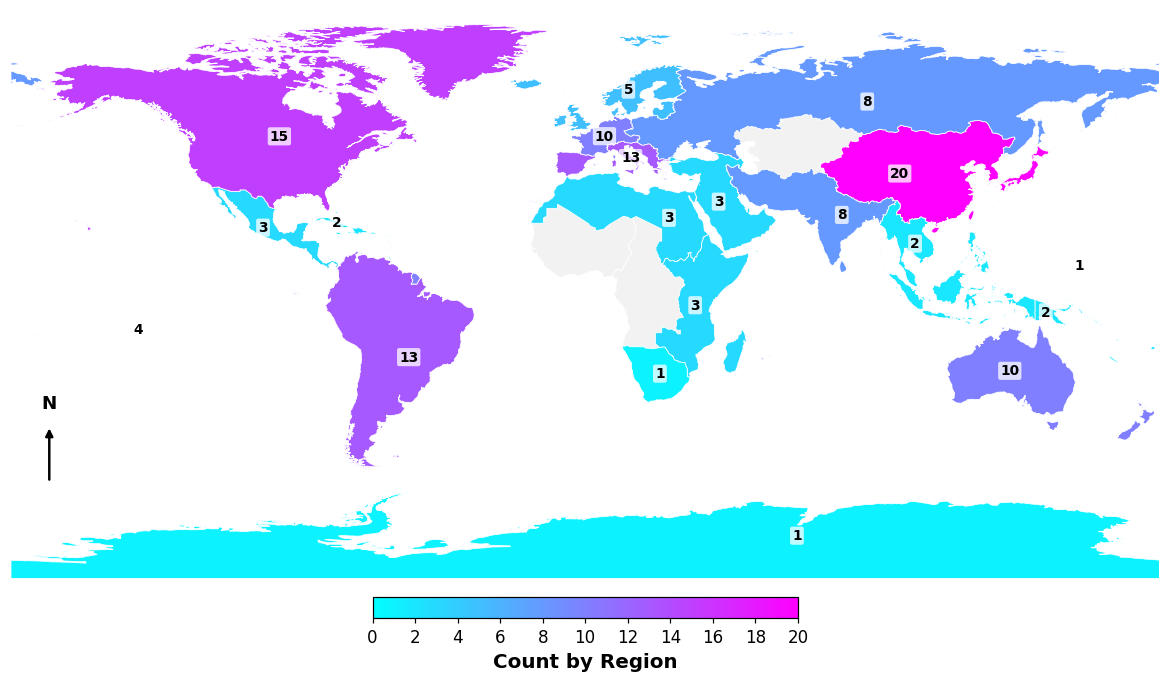

In [5]:
# lon, lat anchors for the two subregions with no visible polygon at world scale
LABEL_ANCHORS = {
    "Micronesia": (155.0, 8.0),
    "Polynesia": (-140.0, -12.0),
}
MIN_LABEL_AREA = 5.0        # square degrees; below this a region needs an anchor
SHOW_ISLAND_NAMES = False   # True prints "Polynesia" / "Micronesia" under those counts

gdf = regions_gdf.copy()
gdf["count"] = gdf["region"].map(counts)

norm = Normalize(vmin=0, vmax=float(counts.max()))
cmap = plt.get_cmap(MAP_CMAP)

fig, ax = plt.subplots(figsize=FIGSIZE[3])

missing = gdf[gdf["count"].isna()]
if not missing.empty:
    missing.plot(ax=ax, color="#F2F2F2", edgecolor="white", linewidth=0.5)
gdf[gdf["count"].notna()].plot(ax=ax, column="count", cmap=cmap, norm=norm,
                               edgecolor="white", linewidth=0.5)
ax.set_aspect("equal")

for _, row in gdf.dropna(subset=["count"]).iterrows():
    region, geom, n = row["region"], row.geometry, int(row["count"])

    if region in LABEL_ANCHORS or geom.area < MIN_LABEL_AREA:
        x, y = LABEL_ANCHORS.get(region, (geom.centroid.x, geom.centroid.y))
        bbox = None
        if SHOW_ISLAND_NAMES:
            ax.text(x, y - 8, region, ha="center", va="top", fontsize=FONTS["map"] - 3,
                    color="#555555", style="italic", zorder=6)
    else:
        part = (max(geom.geoms, key=lambda g: g.area)
                if geom.geom_type == "MultiPolygon" else geom)
        pt = part.representative_point()
        x, y = pt.x, pt.y
        bbox = dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75)

    ax.text(x, y, f"{n}", ha="center", va="center", fontsize=FONTS["map"],
            fontweight="bold", color="black", zorder=6, bbox=bbox)

# north arrow
ax.annotate("", xy=(-168, -42), xytext=(-168, -60),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.6))
ax.text(-168, -38, "N", ha="center", va="bottom",
        fontsize=FONTS["title"], fontweight="bold")

ax.set_xlim(-180, 180)
ax.set_ylim(-92, 88)
ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal",
                    fraction=0.035, pad=0.02, shrink=0.62)
cbar.set_label("Count by Region", fontsize=FONTS["cbar_label"], fontweight="bold")
# Counts are whole studies, so the scale carries no decimals.
cbar.locator = MaxNLocator(integer=True)
cbar.update_ticks()
cbar.ax.tick_params(labelsize=FONTS["tick"])
cbar.outline.set_linewidth(0.8)

fig.tight_layout()
fig.savefig(OUTDIR / "Figure3_geographic_heatmap.png", dpi=DPI)
fig.savefig(OUTDIR / "Figure3_geographic_heatmap.pdf")
plt.show()

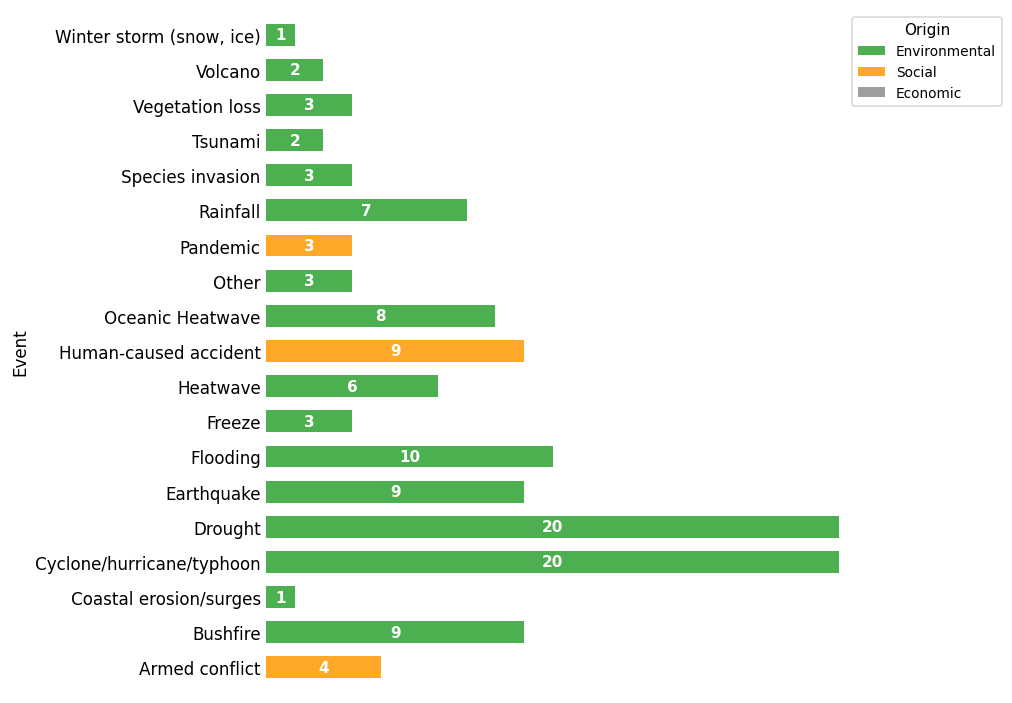

In [6]:
tab4 = pivot_counts(events, "event", "origin", ORIGIN_ORDER)

fig, ax = plt.subplots(figsize=FIGSIZE[4])
stacked_barh(ax, tab4, ORIGIN_ORDER, ORIGIN_COLORS)
ax.set_ylabel("Event", fontsize=FONTS["axis"])
plain_axis(ax)
outside_legend(ax, [Patch(facecolor=ORIGIN_COLORS[o], label=o) for o in ORIGIN_ORDER],
               title="Origin")

fig.tight_layout()
fig.savefig(OUTDIR / "Figure4_event_by_origin.png", dpi=DPI)
plt.show()

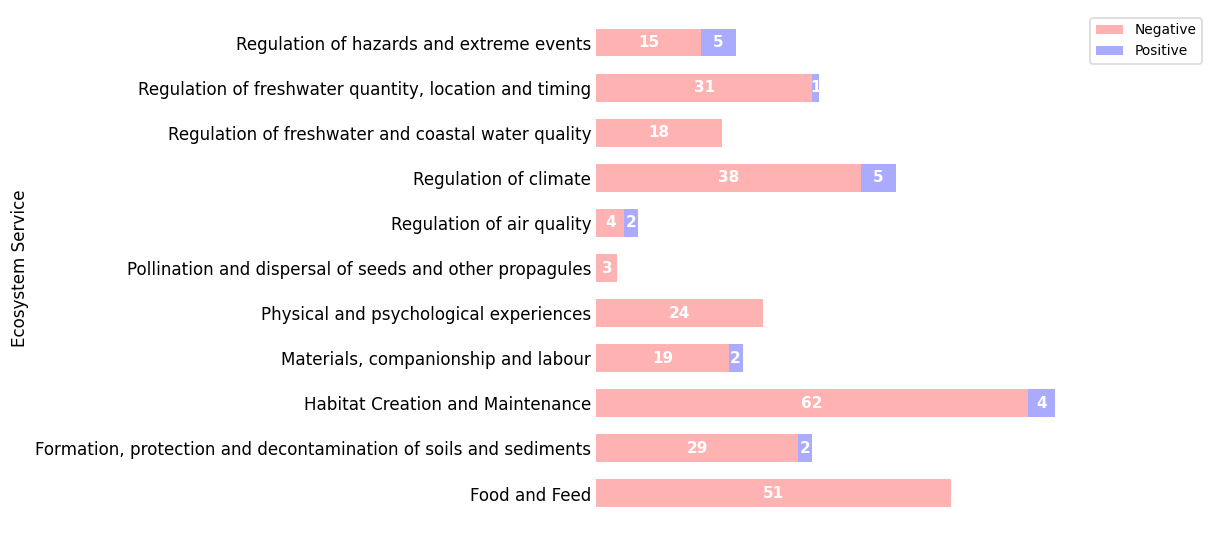

In [7]:
tab5 = pivot_counts(es.dropna(subset=["impact"]), "es", "impact", IMPACT_ORDER)

fig, ax = plt.subplots(figsize=FIGSIZE[5])
stacked_barh(ax, tab5, IMPACT_ORDER, IMPACT_COLORS)
ax.set_ylabel("Ecosystem Service", fontsize=FONTS["axis"])
plain_axis(ax)
outside_legend(ax, [Patch(facecolor=IMPACT_COLORS[i], label=i) for i in IMPACT_ORDER])

fig.tight_layout()
fig.savefig(OUTDIR / "Figure5_ES_by_impact.png", dpi=DPI)
plt.show()

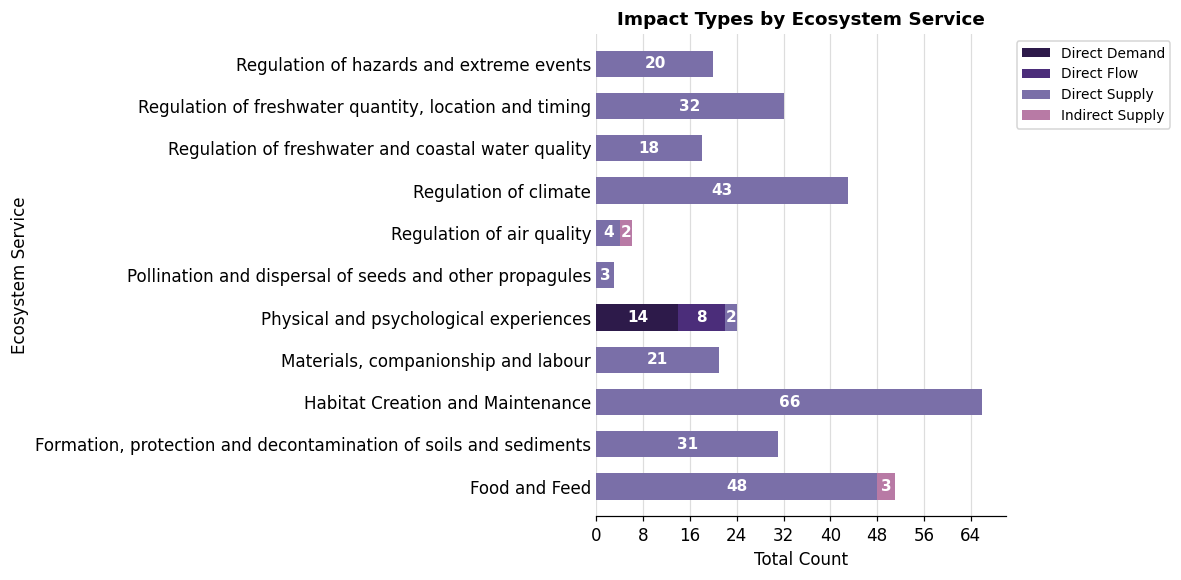

In [8]:
def supply_figure(tab, ylabel, title, fignum, filename):
    fig, ax = plt.subplots(figsize=FIGSIZE[fignum])
    stacked_barh(ax, tab, SUPPLY_ORDER, SUPPLY_COLORS, labels=SUPPLY_LABELS)
    ax.set_ylabel(ylabel, fontsize=FONTS["axis"])
    ax.set_xlabel("Total Count", fontsize=FONTS["axis"])
    ax.set_title(title, fontsize=FONTS["title"], fontweight="bold")
    ax.set_xlim(0, tab.values.sum(axis=1).max() * 1.06)
    ax.xaxis.grid(True, color="#DDDDDD", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["left"].set_visible(False)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="x", labelsize=FONTS["tick"])

    present = [k for k in SUPPLY_ORDER if k in tab.columns and tab[k].sum() > 0]
    outside_legend(ax, [Patch(facecolor=SUPPLY_COLORS[k], label=SUPPLY_LABELS[k])
                        for k in present])

    fig.tight_layout()
    fig.savefig(OUTDIR / filename, dpi=DPI)
    plt.show()


tab6 = pivot_counts(es.dropna(subset=["supply"]), "es", "supply", SUPPLY_ORDER)
supply_figure(tab6, "Ecosystem Service", "Impact Types by Ecosystem Service",
              6, "Figure6_supply_chain_by_ES.png")

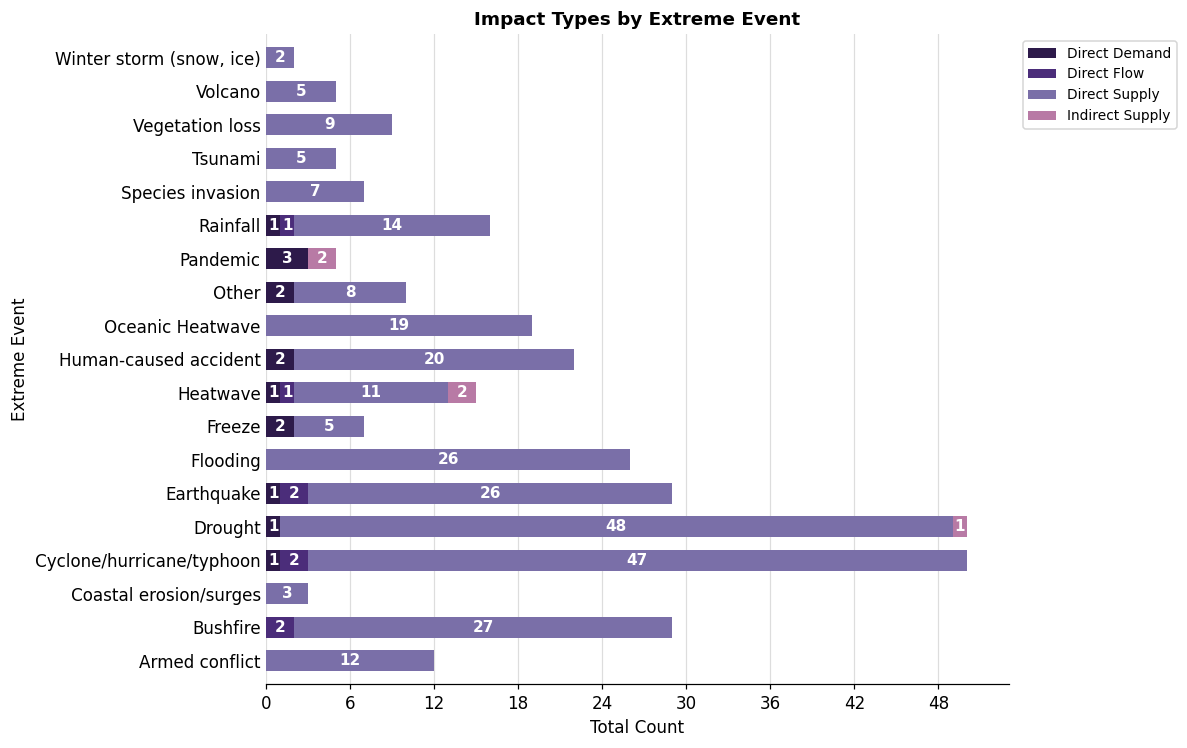

In [9]:
event_supply = pd.DataFrame([
    {"event": e, "supply": r["supply"]}
    for _, r in es.dropna(subset=["supply"]).iterrows()
    for e in r["events"]
])

tab7 = pivot_counts(event_supply, "event", "supply", SUPPLY_ORDER)
supply_figure(tab7, "Extreme Event", "Impact Types by Extreme Event",
              7, "Figure7_supply_chain_by_event.png")

In [10]:
from collections import Counter
from PIL import Image

checks = {}

raw_regions = Counter()
for value in df.loc[~is_global, "Geographic region"] if EXCLUDE_GLOBAL_FROM_MAP \
        else df["Geographic region"]:
    for token in str(value).split(";"):
        raw_regions[token.strip()] += 1
checks["region counts"] = (dict(counts) == dict(raw_regions))
checks["global studies excluded from map"] = (
    EXCLUDE_GLOBAL_FROM_MAP and int(is_global.sum()) == 3 and n_represented == len(df) - 3)
checks["Figure 3 caption arithmetic"] = (
    n_displayed - n_represented
    == sum(len(split_list(v)) - 1 for v in map_df["Geographic region"]))

raw_events = sum(len(str(v).split(";")) for v in df["What was the event?"])
checks["Fig 4 event mentions"] = (int(tab4.values.sum()) == raw_events == len(events))

raw_es = sum(df[f"Ecosystem service {i}"].notna().sum() for i in range(1, 5))
checks["ES records stacked"] = (len(es) == raw_es)
checks["Fig 5 = ES records with impact"] = (int(tab5.values.sum()) == es["impact"].notna().sum())
checks["Fig 6 = ES records with supply"] = (int(tab6.values.sum()) == es["supply"].notna().sum())
checks["Fig 7 = per-event expansion"] = (
    int(tab7.values.sum()) == sum(len(r) for r in es.dropna(subset=["supply"])["events"]))
checks["mapped regions have geometry"] = set(counts.index) <= set(regions_gdf["region"])
checks["all coded regions have geometry"] = all_coded_regions <= set(regions_gdf["region"])

for name, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL'}  {name}")

caption = (
    f"Figure 3: Geographic distribution of studies included in the systematic review, "
    f"classified by UN M49 geographic region. Numbers indicate the count of studies whose "
    f"primary study area fell within each region. Regions are coloured according to study "
    f"count. {int(is_global.sum())} studies with global scope (covering all regions) are "
    f"excluded from this figure. {n_multi} studies covered multiple non-global regions and "
    f"are therefore counted in each of their respective regions, meaning the sum of all "
    f"displayed counts (n = {n_displayed}) exceeds the number of studies represented "
    f"(n = {n_represented}).")
if no_data_regions:
    caption += (f" {len(no_data_regions)} regions ({', '.join(no_data_regions)}) are covered "
                f"only by the excluded global-scope studies and therefore appear as having "
                f"no studies.")
print("\n--- Figure 3 caption, generated from the data ---")
print(caption)

print(f"\n{'figure':<40}{'pixels':<16}{'page size':<18}April page size")
for n, (aw, ah) in sorted(APRIL_PIXELS.items()):
    path = next(OUTDIR.glob(f"Figure{n}_*.png"))
    w, h = Image.open(path).size
    tag = "MATCH" if (w, h) == (aw * DPI // APRIL_DPI, ah * DPI // APRIL_DPI) else "DIFFERS"
    print(f"{path.name:<40}{f'{w} x {h}':<16}"
          f"{f'{w/DPI:.2f} x {h/DPI:.2f} in':<18}{aw/APRIL_DPI:.2f} x {ah/APRIL_DPI:.2f} in  {tag}")

PASS  region counts
PASS  global studies excluded from map
PASS  Figure 3 caption arithmetic
PASS  Fig 4 event mentions
PASS  ES records stacked
PASS  Fig 5 = ES records with impact
PASS  Fig 6 = ES records with supply
PASS  Fig 7 = per-event expansion
PASS  mapped regions have geometry
PASS  all coded regions have geometry

--- Figure 3 caption, generated from the data ---
Figure 3: Geographic distribution of studies included in the systematic review, classified by UN M49 geographic region. Numbers indicate the count of studies whose primary study area fell within each region. Regions are coloured according to study count. 3 studies with global scope (covering all regions) are excluded from this figure. 4 studies covered multiple non-global regions and are therefore counted in each of their respective regions, meaning the sum of all displayed counts (n = 127) exceeds the number of studies represented (n = 118). 3 regions (Central Asia, Middle Africa, Western Africa) are covered only b